# 4.1. Create the noisy signal and plot it

###We redo the remarkable points analysis on the signal of part 3 with added **white noise**, then remove the noise with a **low-pass filter**.

In [43]:
import numpy as np
import matplotlib.pyplot as plt

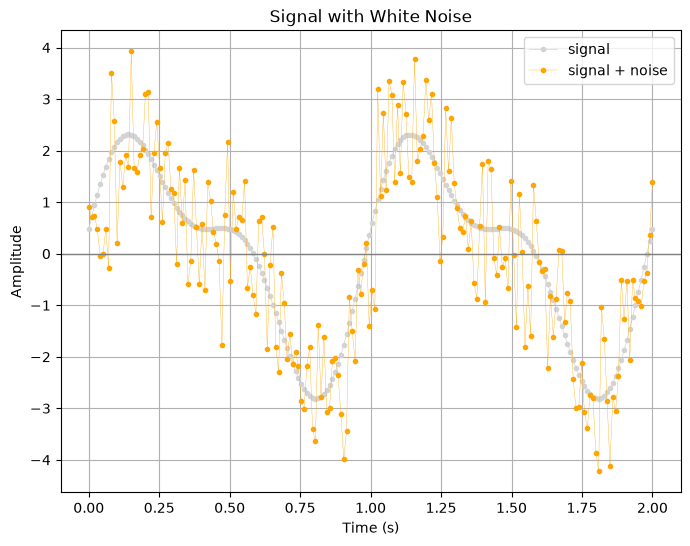

In [44]:

 
# time axis
time = np.linspace(0, 2, 200)
 
# signal
signal = (
2*np.sin(2*np.pi*time)
+ np.sin(4*np.pi*time + 0.5)
)
 
# white noise
noise_amplitude = 0.9644505235820642
noise = noise_amplitude * np.random.randn(len(time))
 
# noisy signal
signal_noise = signal + noise
 
plt.figure(figsize=(8,6))
 
# original signal
plt.plot(
time,
signal,
'o-',
color='lightgray',
markersize=3,
linewidth=0.5,
label='signal'
)
 
# noisy signal
plt.plot(
time,
signal_noise,
'o-',
color='orange',
markersize=3,
linewidth=0.25, # required
label='signal + noise'
)
 
plt.axhline(
y=0,
color='gray',
linewidth=1
)
 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal with White Noise")
 
plt.legend()
plt.grid(True)
 
plt.show()

##4.2. Plot the remarkable points in the noisy signal
We add **white noise** (uniform random values, generated with `np.random`) to the clean signal `s` of part 3.
The noise amplitude is **20 % of the peak-to-peak amplitude** of the signal. A fixed seed makes the result reproducible.

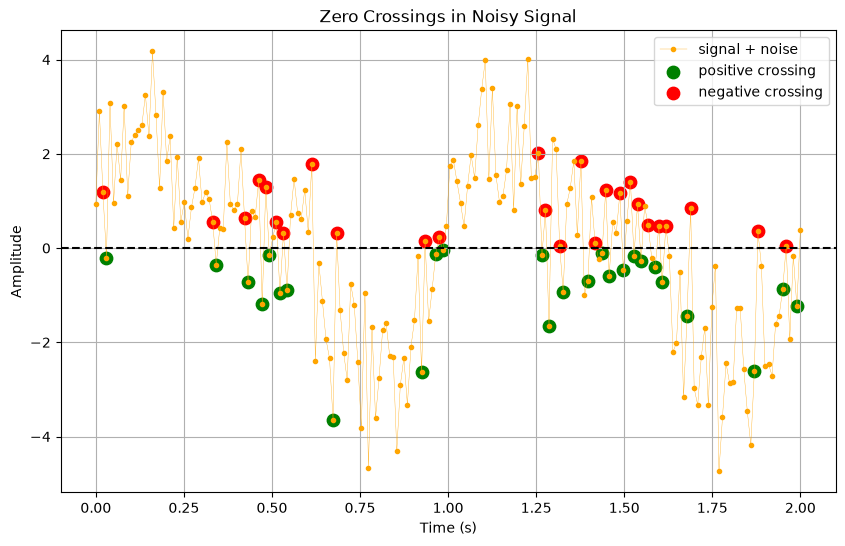

In [45]:
signal_sign = np.sign(signal_noisy)
diff_signal_sign = np.diff(signal_sign)
 
positive_zero_crossings = np.where(diff_signal_sign > 0)[0]
negative_zero_crossings = np.where(diff_signal_sign < 0)[0]
 
plt.figure(figsize=(10,6))
 
# noisy signal
plt.plot(
time,
signal_noisy,
'o-',
color='orange',
markersize=3,
linewidth=0.25,
label='signal + noise'
)
 
# positive crossings
plt.scatter(
time[positive_zero_crossings],
signal_noisy[positive_zero_crossings],
color='green',
s=80,
label='positive crossing'
)
 
# negative crossings
plt.scatter(
time[negative_zero_crossings],
signal_noisy[negative_zero_crossings],
color='red',
s=80,
label='negative crossing'
)
 
plt.axhline(y=0,color='black',linestyle='--')
 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Zero Crossings in Noisy Signal")
plt.legend()
plt.grid(True)
 
plt.show()

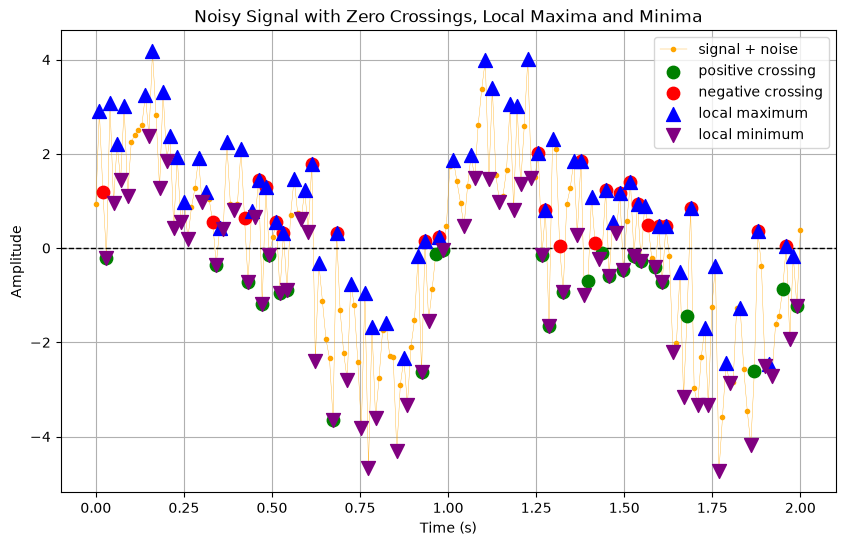

In [46]:
from scipy.signal import argrelextrema
from scipy.signal import butter, filtfilt

# ==========================================
# 1. Find local maxima and local minima
# ==========================================

local_maxima = argrelextrema(
    signal_noisy,
    np.greater
)[0]

local_minima = argrelextrema(
    signal_noisy,
    np.less
)[0]


# ==========================================
# 2. Create the figure
# ==========================================

plt.figure(figsize=(10, 6))


# ==========================================
# 3. Plot the noisy signal
# ==========================================

plt.plot(
    time,
    signal_noisy,
    'o-',
    color='orange',
    markersize=3,
    linewidth=0.25,
    label='signal + noise'
)


# ==========================================
# 4. Plot positive zero crossings
# ==========================================

plt.scatter(
    time[positive_zero_crossings],
    signal_noisy[positive_zero_crossings],
    color='green',
    s=80,
    label='positive crossing',
    zorder=3
)


# ==========================================
# 5. Plot negative zero crossings
# ==========================================

plt.scatter(
    time[negative_zero_crossings],
    signal_noisy[negative_zero_crossings],
    color='red',
    s=80,
    label='negative crossing',
    zorder=3
)


# ==========================================
# 6. Plot local maxima
# ==========================================

plt.scatter(
    time[local_maxima],
    signal_noisy[local_maxima],
    color='blue',
    marker='^',
    s=100,
    label='local maximum',
    zorder=4
)


# ==========================================
# 7. Plot local minima
# ==========================================

plt.scatter(
    time[local_minima],
    signal_noisy[local_minima],
    color='purple',
    marker='v',
    s=100,
    label='local minimum',
    zorder=4
)


# ==========================================
# 8. Add zero reference line
# ==========================================

plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)


# ==========================================
# 9. Labels and formatting
# ==========================================

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.title(
    "Noisy Signal with Zero Crossings, "
    "Local Maxima and Minima"
)

plt.legend()
plt.grid(True)

plt.show()

##4.3. Low pass filter the noisy signal

Sampling frequency (Hz): 100


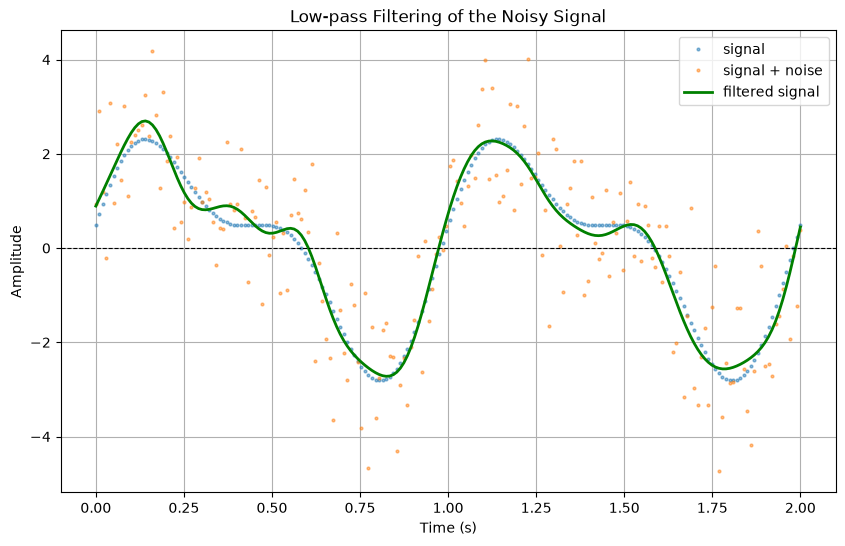

In [48]:
 #1. Calculate the sampling frequency
# ==========================================

dt = np.mean(np.diff(time))
fs = 100

print("Sampling frequency (Hz):", fs)


# ==========================================
# 2. Define the low-pass filter
# ==========================================

cutoff_frequency = 5      # Hz
filter_order = 4

# Create Butterworth low-pass filter
b, a = butter(
    filter_order,
    cutoff_frequency,
    btype='low',
    fs=fs
)


# ==========================================
# 3. Apply the filter
# ==========================================

filtered_signal = filtfilt(
    b,
    a,
    signal_noisy
)


# ==========================================
# 4. Plot the signals
# ==========================================

plt.figure(figsize=(10, 6))

# Original clean signal
plt.plot(
    time,
    signal,
    'o',
    markersize=2,
    alpha=0.5,
    label='signal'
)

# Noisy signal
plt.plot(
    time,
    signal_noisy,
    'o',
    markersize=2,
    alpha=0.5,
    label='signal + noise'
)

# Filtered signal
plt.plot(
    time,
    filtered_signal,
    color='green',
    linewidth=2,
    label='filtered signal'
)


# Zero reference line
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=0.8
)


plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Low-pass Filtering of the Noisy Signal")

plt.legend()
plt.grid(True)

plt.show()